🔍 Loaded 34,567 rows across 227 columns
📊 Texas counties with complete records for 2018: 254
💵 Infant center care ranges from $109 to $202 per week
⚖️ Infant burden ranges from 8.8% to 29.4% of income
🏠 Infant home care ranges from $97 to $177 per week


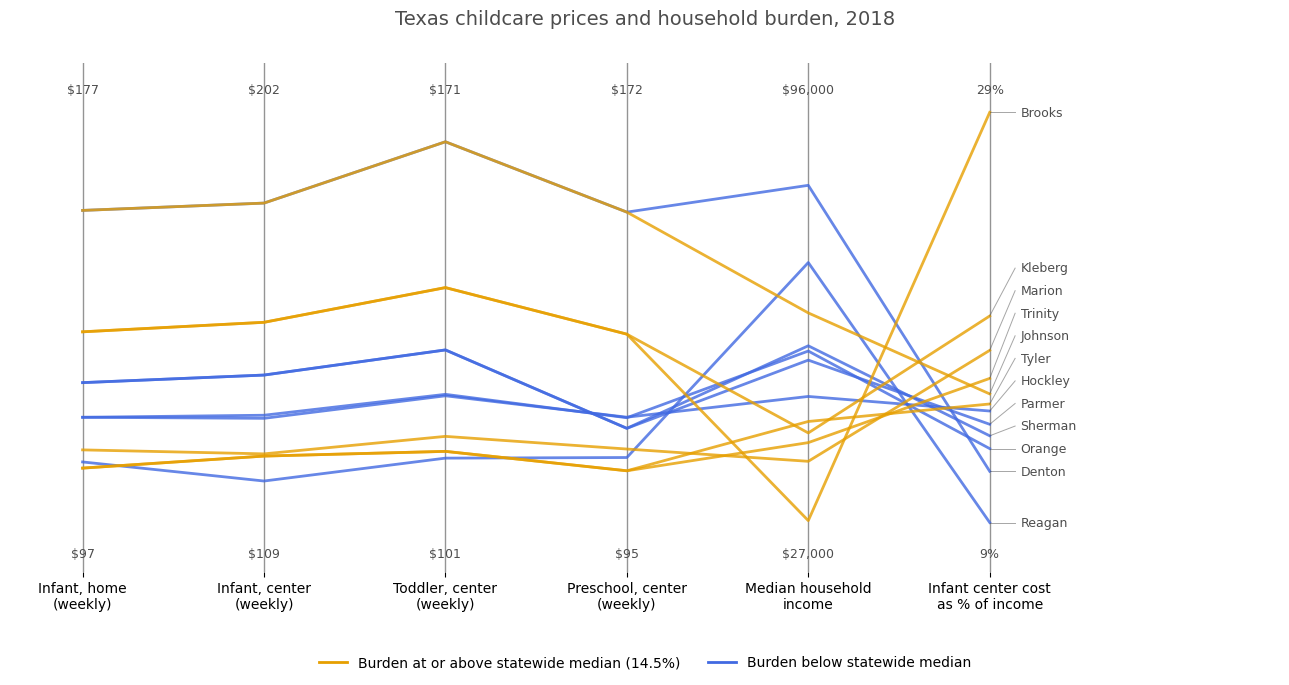

✅ Saved viz_parcoords_childcare_tx.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROYAL_BLUE = '#4169E1'
AMBER = '#E69F00'
DARK_GRAY = '#4D4D4D'

CHILDCARE_PATH = 'nationaldatabaseofchildcareprices.xlsx'

COLS = {
    'county': 'County_Name',
    'state': 'State_Name',
    'year': 'StudyYear',
    'fcc_infant': 'MFCCInfant',
    'center_infant': 'MCInfant',
    'center_toddler': 'MCToddler',
    'center_preschool': 'MCPreschool',
    'income': 'MHI',
}

PLOT_AXES = [
    'fcc_infant',
    'center_infant',
    'center_toddler',
    'center_preschool',
    'income',
    'burden']
AXIS_LABELS = [
    'Infant, home\n(weekly)',
    'Infant, center\n(weekly)',
    'Toddler, center\n(weekly)',
    'Preschool, center\n(weekly)',
    'Median household\nincome',
    'Infant center cost\nas % of income',
]

STUDY_YEAR = 2018
WEEKS_PER_YEAR = 52
N_COUNTIES = 12

raw = pd.read_excel(CHILDCARE_PATH)
print(f'🔍 Loaded {raw.shape[0]:,} rows across {raw.shape[1]:,} columns')

missing = [name for name in COLS.values() if name not in raw.columns]
if missing:
    print(f'🛑 These COLS entries are not in the file: {missing}')
    print('📋 Columns that look like candidates:')
    keywords = [
        'county',
        'state',
        'year',
        'infant',
        'toddler',
        'preschool',
        'school',
        'income',
        'mhi']
    for col in raw.columns:
        if any(k in col.lower() for k in keywords):
            print(f'   • {col}')
    raise SystemExit('Fix COLS above and re-run.')


texas = raw[(raw[COLS['state']] == 'Texas') & (
    raw[COLS['year']] == STUDY_YEAR)].copy()
texas = texas.rename(columns={v: k for k, v in COLS.items()})
texas['burden'] = (texas['center_infant'] *
                   WEEKS_PER_YEAR) / texas['income'] * 100
texas = texas.dropna(subset=PLOT_AXES)

print(
    f'📊 Texas counties with complete records for {STUDY_YEAR}: {len(texas):,}')
print(
    f'💵 Infant center care ranges from ${texas["center_infant"].min():,.0f} to ${texas["center_infant"].max():,.0f} per week')
print(
    f'⚖️ Infant burden ranges from {texas["burden"].min():,.1f}% to {texas["burden"].max():,.1f}% of income')
print(
    f'🏠 Infant home care ranges from ${texas["fcc_infant"].min():,.0f} to ${texas["fcc_infant"].max():,.0f} per week')

ranked = texas.sort_values('burden').reset_index(drop=True)
picks = np.linspace(0, len(ranked) - 1, N_COUNTIES).round().astype(int)
sample = ranked.loc[picks].copy()
burden_split = texas['burden'].median()

scaled = sample[PLOT_AXES].copy()
bounds = {}
for col in PLOT_AXES:
    lo, hi = texas[col].min(), texas[col].max()
    bounds[col] = (lo, hi)
    scaled[col] = (sample[col] - lo) / (hi - lo)

fig, ax = plt.subplots(figsize=(13, 7))
positions = np.arange(len(PLOT_AXES))

for idx in scaled.index:
    line_color = AMBER if sample.loc[idx,
                                     'burden'] >= burden_split else ROYAL_BLUE
    ax.plot(positions,
            scaled.loc[idx,
                       PLOT_AXES].values,
            color=line_color,
            alpha=0.8,
            linewidth=2)

for pos, col in enumerate(PLOT_AXES):
    ax.axvline(pos, color=DARK_GRAY, linewidth=1, alpha=0.6, zorder=0)
    lo, hi = bounds[col]
    prefix = '' if col == 'burden' else '$'
    unit = '%' if col == 'burden' else ''
    if col == 'income':
        lo_text = f'{prefix}{round(lo, -3):,.0f}{unit}'
        hi_text = f'{prefix}{round(hi, -3):,.0f}{unit}'
    else:
        lo_text = f'{prefix}{lo:,.0f}{unit}'
        hi_text = f'{prefix}{hi:,.0f}{unit}'
    ax.text(pos, -0.06, lo_text, ha='center',
            va='top', fontsize=9, color=DARK_GRAY)
    ax.text(
        pos,
        1.04,
        hi_text,
        ha='center',
        va='bottom',
        fontsize=9,
        color=DARK_GRAY)

label_rows = sorted([(scaled.loc[idx, 'burden'], sample.loc[idx, 'county'].replace(
    ' County', '')) for idx in scaled.index], key=lambda pair: pair[0])

min_gap = 0.055
placed = []
for value, name in label_rows:
    target = value if not placed else max(value, placed[-1][0] + min_gap)
    placed.append((target, value, name))

overflow = placed[-1][0] - 1.0
if overflow > 0:
    placed = [(target - overflow, value, name)
              for target, value, name in placed]

x_end = len(PLOT_AXES) - 1
for target, value, name in placed:
    ax.plot([x_end, x_end + 0.14], [value, target],
            color=DARK_GRAY, linewidth=0.7, alpha=0.5)
    ax.text(
        x_end + 0.17,
        target,
        name,
        ha='left',
        va='center',
        fontsize=9,
        color=DARK_GRAY)

ax.set_xticks(positions)
ax.set_xticklabels(AXIS_LABELS, fontsize=10)
ax.set_yticks([])
ax.set_xlim(-0.4, len(PLOT_AXES) + 0.6)
ax.set_ylim(-0.12, 1.12)
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [
    Line2D(
        [0],
        [0],
        color=AMBER,
        linewidth=2,
        label=f'Burden at or above statewide median ({burden_split:,.1f}%)'),
    Line2D(
        [0],
        [0],
        color=ROYAL_BLUE,
        linewidth=2,
        label='Burden below statewide median'),
]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(
    0.5, -0.14), ncol=2, frameon=False, fontsize=10)
ax.set_title(
    f'Texas childcare prices and household burden, {STUDY_YEAR}',
    fontsize=14,
    color=DARK_GRAY,
    pad=28)

plt.tight_layout()
plt.savefig('viz_parcoords_childcare_tx.png', dpi=200, bbox_inches='tight')
plt.show()

print('✅ Saved viz_parcoords_childcare_tx.png')